<a href="https://colab.research.google.com/github/sonalismore/pandas_exercises/blob/master/NLP_ChatBot_Basic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

**DOMAIN:** Industrial safety. NLP-based Chatbot.

**CONTEXT:**  
The database comes from one of the biggest industries in Brazil and in the world.  
It is an urgent need for industries/companies around the globe to understand why employees still suffer some injuries/accidents in plants. Sometimes they also die in such environments.

**DATA DESCRIPTION:**  
The database is basically records of accidents from 12 different plants in 3 different countries.  
Each line in the data is an occurrence of an accident.

**Columns Description:**
- **Data**: Timestamp or time/date information  
- **Countries**: Which country the accident occurred (anonymized)  
- **Local**: The city where the manufacturing plant is located (anonymized)  
- **Industry sector**: Which sector the plant belongs to  
- **Accident level**: From I to VI, it registers how severe the accident was (I = not severe, VI = very severe)  
- **Potential Accident Level**: Depending on the accident level, the database also registers how severe the accident *could* have been (due to other factors)  
- **Genre**: Whether the person is male or female  
- **Employee or Third Party**: Whether the injured person is an employee or a third party  
- **Critical Risk**: Description of the risk involved in the accident  
- **Description**: Detailed description of how the accident happened  


# **Importing necessary libraries, creating dataframe**

## **Import Libraries**


In [ ]:
#Import all the necessary modules
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score
import copy
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from random import randint

## **Importing Data**

In [ ]:
#Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df=pd.read_excel('/content/drive/My Drive/GL_2024/Capstone-chatbot/industry_accident_safety.xls')

In [ ]:
print("Number of rows = {0} and Number of Columns = {1} in the Data frame".format(df.shape[0], df.shape[1]))


Number of rows = 425 and Number of Columns = 11 in the Data frame


In [ ]:
data=df.copy()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Unnamed: 0                425 non-null    int64         
 1   Data                      425 non-null    datetime64[ns]
 2   Countries                 425 non-null    object        
 3   Local                     425 non-null    object        
 4   Industry Sector           425 non-null    object        
 5   Accident Level            425 non-null    object        
 6   Potential Accident Level  425 non-null    object        
 7   Genre                     425 non-null    object        
 8   Employee or Third Party   425 non-null    object        
 9   Critical Risk             425 non-null    object        
 10  Description               425 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 36.7+ KB


In [ ]:
data.shape

(425, 11)

In [ ]:
data.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...
2,2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...
3,3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...
4,4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...


Observations:

The data-frame has 425 rows and 11 columns with the following data types:

1.   datetime64(1)
2.   int64(1)
3.   object(9)



# **Data Cleansing**

From the dataset, we need cleanse the data by doing the following

1. Remove the "Unnamed: 0" column as it is unnecessary.
2. Rename the "Data" column to "Date" since it represents date values.
3. Rename the "Countries" column to "Country".
4. Rename the "Genre" column to "Gender" to correctly reflect its content.
5. Rename the "Employee or Third Party" column to "Employee Type".
6. Check and drop Duplicate values
7. Check and drop null values
8. Extracting Date object as new columns

In [ ]:
# Remove 'Unnamed: 0' column from Data frame
data.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
# Rename columns in the Data frame as mentioned above
data.rename(columns={'Data':'Date', 'Countries':'Country', 'Genre':'Gender', 'Employee or Third Party':'Employee Type'}, inplace=True)

In [ ]:
# Check duplicates in a data frame
data.duplicated().sum()

np.int64(7)

In [ ]:
#Viewing the duplicates in the Data frame
duplicates = data.duplicated()
data[duplicates]

,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee Type,Critical Risk,Description
77,2016-04-01,Country_01,Local_01,Mining,I,V,Male,Third Party (Remote),Others,In circumstances that two workers of the Abrat...
262,2016-12-01,Country_01,Local_03,Mining,I,IV,Male,Employee,Others,During the activity of chuteo of ore in hopper...
303,2017-01-21,Country_02,Local_02,Mining,I,I,Male,Third Party (Remote),Others,Employees engaged in the removal of material f...
345,2017-03-02,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
346,2017-03-02,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,On 02/03/17 during the soil sampling in the re...
355,2017-03-15,Country_03,Local_10,Others,I,I,Male,Third Party,Venomous Animals,Team of the VMS Project performed soil collect...
397,2017-05-23,Country_01,Local_04,Mining,I,IV,Male,Third Party,Projection of fragments,In moments when the 02 collaborators carried o...


In [ ]:
#Dropping duplicates as removing them wouldnt affect the overall quality of the data frame
data.drop_duplicates(inplace=True)

In [ ]:
#Checking null values
data.isnull().sum()

,0
Date,0
Country,0
Local,0
Industry Sector,0
Accident Level,0
Potential Accident Level,0
Gender,0
Employee Type,0
Critical Risk,0
Description,0


In [ ]:
# Ensure 'Date' is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract time-based features as new columns
data['Year'] = data['Date'].apply(lambda x: x.year)
data['Month'] = data['Date'].apply(lambda x: x.month)
data['Day'] = data['Date'].apply(lambda x: x.day)
data['Weekday'] = data['Date'].apply(lambda x: x.day_name())
data['WeekOfYear']=data['Date'].dt.strftime('%U')
data["Is_Weekend"] =data['Date'].dt.day_name().isin(['Saturday', 'Sunday'])


In [ ]:
roman_dict={'I':1,'II':2,'III':3,'IV':4,'V':5,'VI':6}
roman_dict

{'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6}

In [ ]:
data['Accident Level'] = data['Accident Level'].replace(roman_dict)

In [ ]:
data['Potential Accident Level'] = data['Potential Accident Level'].replace(roman_dict)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 0 to 424
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      418 non-null    datetime64[ns]
 1   Country                   418 non-null    object        
 2   Local                     418 non-null    object        
 3   Industry Sector           418 non-null    object        
 4   Accident Level            418 non-null    int64         
 5   Potential Accident Level  418 non-null    int64         
 6   Gender                    418 non-null    object        
 7   Employee Type             418 non-null    object        
 8   Critical Risk             418 non-null    object        
 9   Description               418 non-null    object        
 10  Year                      418 non-null    int64         
 11  Month                     418 non-null    int64         
 12  Day                       4

## Data Cleaning Summary

- **Removed unnecessary column:** Dropped the redundant `"Unnamed: 0"` column.
- **Renamed columns for clarity and consistency:** Renamed 4 columns for improved clarity and consistency.
- **Duplicate data handling:** Removed 7 duplicate rows after review.
- **Column List:** Dataset includes key fields such as `Date`, `Country`, `Gender`, and `Description`.
- **Null Value Check:** No missing values found in the dataset.
- Extracted **Date** object into `Year`,`Month`,`Day`, and `Weekday`.
- **Final DataFrame Overview (After Cleansing):** Final dataset contains **418 entries** and **14 columns**.
- **Data Types:** Dataset includes **1 datetime column** , **4 int column** and **9 categorical columns**.

**DataSet Analysis- Basic EDA**

In [ ]:
for col in data.columns:
  #print(col)
  if (data[col].dtype=='object' or data[col].dtype=='int32') and col not in ['Day','Description','WeekOfYear']:
    data[col]=pd.Categorical(data[col])


In [ ]:
cat_cols=data.select_dtypes(include=['category']).columns
for col in cat_cols:
  print(data[col].value_counts())
  print('-'*50)

Country
Country_01    248
Country_02    129
Country_03     41
Name: count, dtype: int64
--------------------------------------------------
Local
Local_03    89
Local_05    59
Local_01    56
Local_04    55
Local_06    46
Local_10    41
Local_08    27
Local_02    23
Local_07    14
Local_12     4
Local_09     2
Local_11     2
Name: count, dtype: int64
--------------------------------------------------
Industry Sector
Mining    237
Metals    134
Others     47
Name: count, dtype: int64
--------------------------------------------------
Gender
Male      396
Female     22
Name: count, dtype: int64
--------------------------------------------------
Employee Type
Third Party             185
Employee                178
Third Party (Remote)     55
Name: count, dtype: int64
--------------------------------------------------
Critical Risk
Others                                       229
Pressed                                       24
Manual Tools                                  20
Chemical substa

In [ ]:
def labeled_barplot(data, feature,Target, perc=False, n=None):
  total = len(data[feature])  # length of the column
  count = data[feature].nunique()
  #if n is None:
  #  plt.figure(figsize=(count + 2, 6))
  #else:
  #  plt.figure(figsize=(n + 2, 6))

  fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

  ax[0].set_title('Countplot for feature ' + feature)

  sns.countplot(
        data=data,
        x=feature,
      # hue=Target,
        palette="Paired",        ax=ax[0],
        order=data[feature].value_counts().index[:n],
  )
  ax[0].tick_params(labelrotation=90)

  for p in ax[0].patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax[0].annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=6,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

  ax[1].set_title('Countplot for feature ' + feature + ' with respect to ' + Target)
  sns.countplot(
        data=data,
        x=feature,
        hue=Target,
        palette="Paired",ax=ax[1],
        order=data[feature].value_counts().index[:n],
  )

  for p in ax[1].patches:
       if perc == True:
           label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
           #print(label)
       else:
        label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax[1].annotate(
           label,
           (x, y),
          ha="center",
          va="center",
           size=6,
            xytext=(0, 5),
            textcoords="offset points",
        )
  plt.xticks(rotation=90);
  plt.tight_layout()

In [ ]:
def labeled_barplot_uni(data, feature, perc=False, n=None):
  total = len(data[feature])  # length of the column
  count = data[feature].nunique()
  if n is None:
    plt.figure(figsize=(count + 2, 6))
  else:
    plt.figure(figsize=(n + 2, 6))
  plt.xticks(rotation=90, fontsize=15)
  ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
  )
  ax.set_title('Countplot for feature ' + feature)

  for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

  plt.show()

**Univariate Analysis Countries**


In [ ]:
data.head()

,Date,Country,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee Type,Critical Risk,Description,Year,Month,Day,Weekday,WeekOfYear,Is_Weekend
0,2016-01-01,Country_01,Local_01,Mining,1,4,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,2016,1,1,Friday,00,False
1,2016-01-02,Country_02,Local_02,Mining,1,4,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,2016,1,2,Saturday,00,True
2,2016-01-06,Country_01,Local_03,Mining,1,3,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,2016,1,6,Wednesday,01,False
3,2016-01-08,Country_01,Local_04,Mining,1,1,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,2016,1,8,Friday,01,False
4,2016-01-10,Country_01,Local_04,Mining,4,4,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,2016,1,10,Sunday,02,True


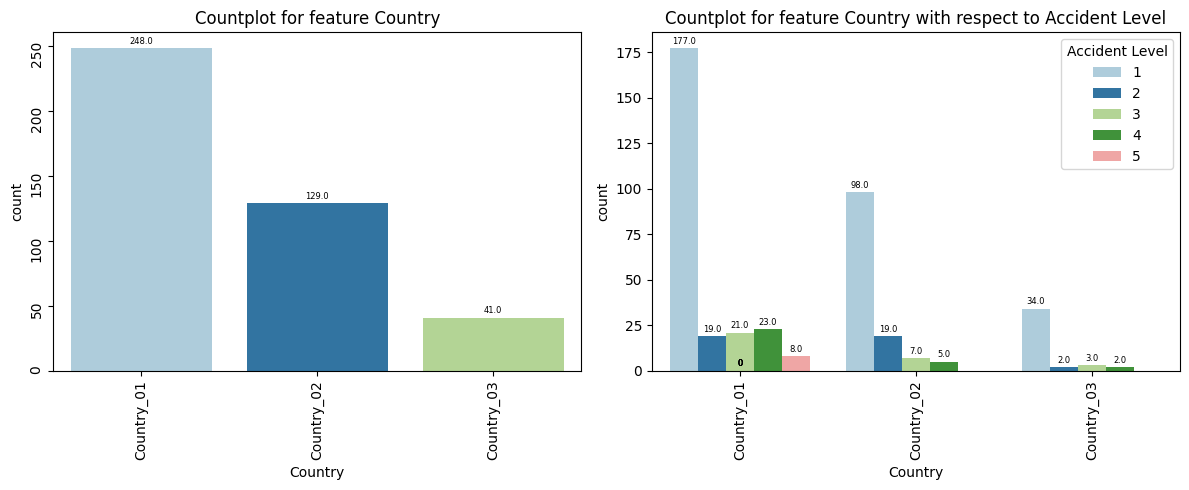

In [ ]:
labeled_barplot(data,'Country', 'Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Local**

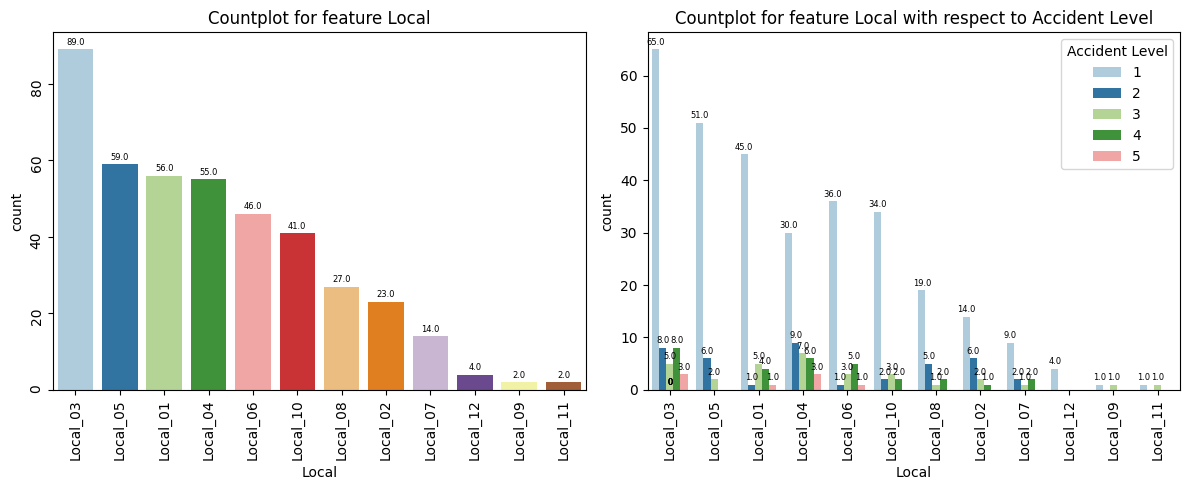

In [ ]:
labeled_barplot(data,'Local', 'Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Industry Sector**

Which idustry sector has maximum chance having hazardous accidents?

**Bivariate Analysis Industry Sector with respect to Accident Level**


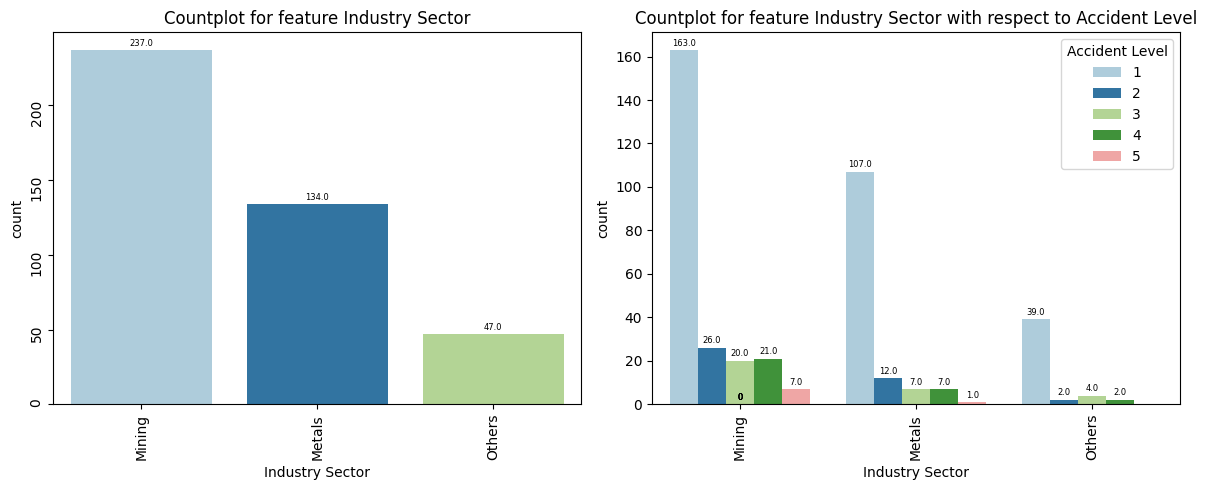

In [ ]:
labeled_barplot(data,'Industry Sector', 'Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Accident Level**

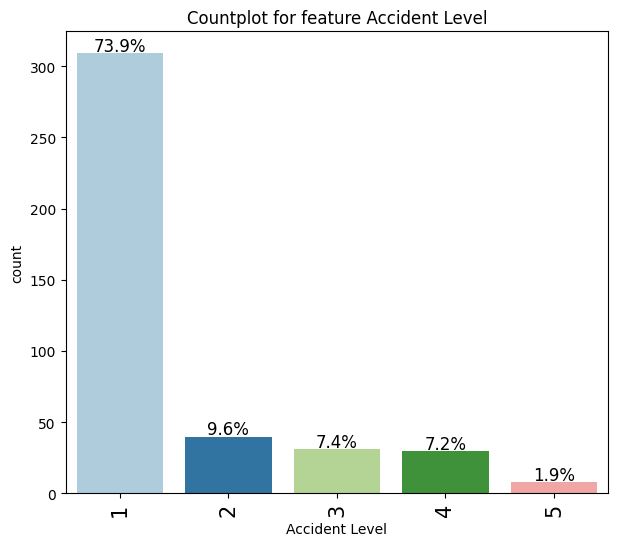

In [ ]:
labeled_barplot_uni(data,'Accident Level',perc=True, n=None)

**Observation**

**Univariate Analysis Potential Accident Level**

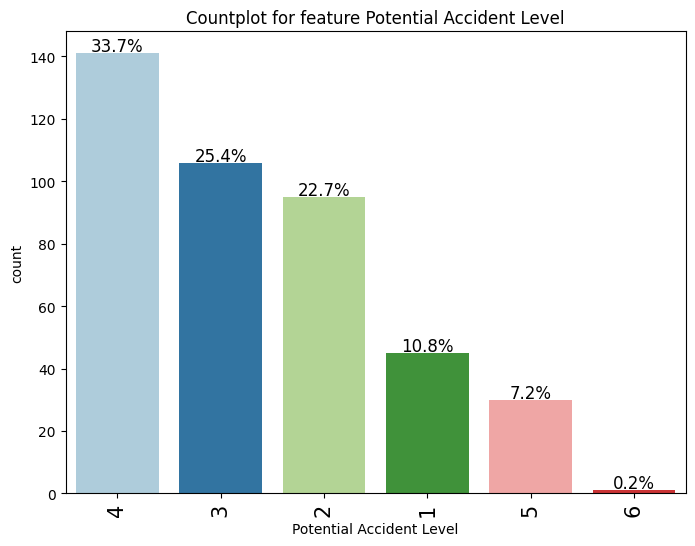

In [ ]:
labeled_barplot_uni(data,'Potential Accident Level',perc=True, n=None)

**Observation**



What % of accidents have potential to turn to distaster?

**Bivariate analysis of accident level and potential accident level**


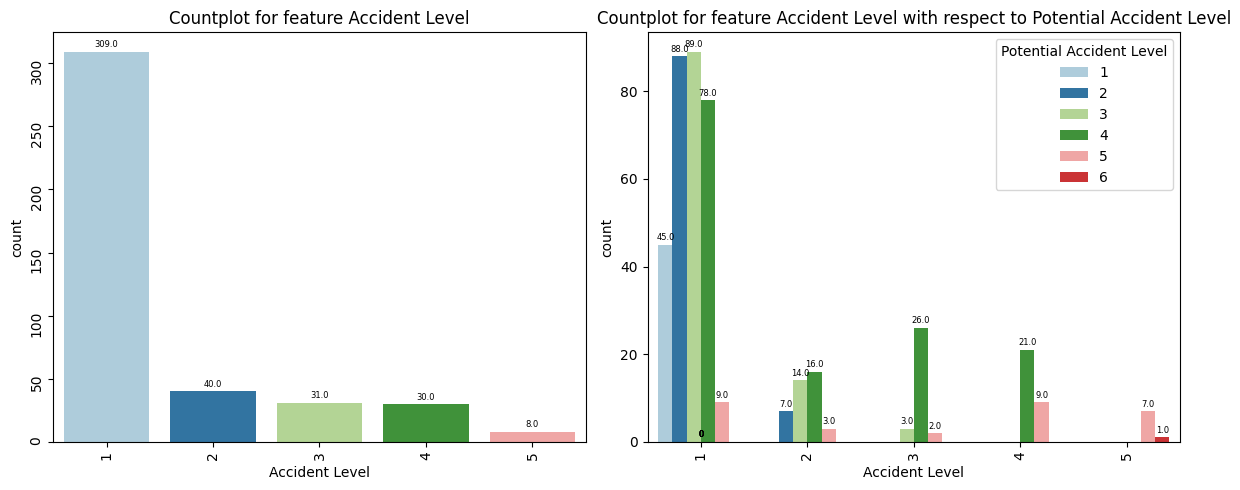

In [ ]:
labeled_barplot(data,'Accident Level','Potential Accident Level',perc=False, n=None)

**Observation**

**Univariate Analysis Gender**

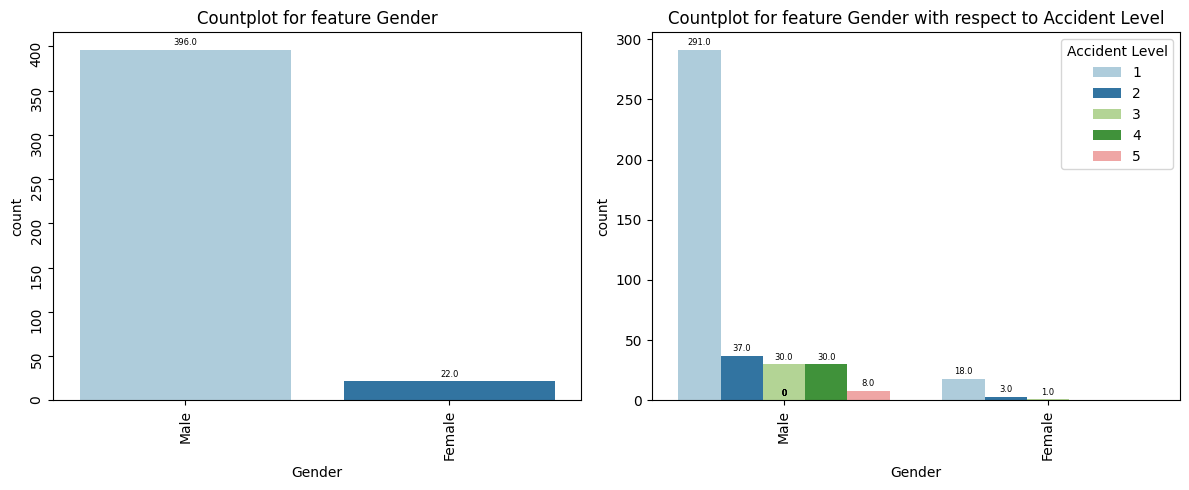

In [ ]:
labeled_barplot(data,'Gender', 'Accident Level',perc=False, n=None)

**Univariate Analysis Employee Type**

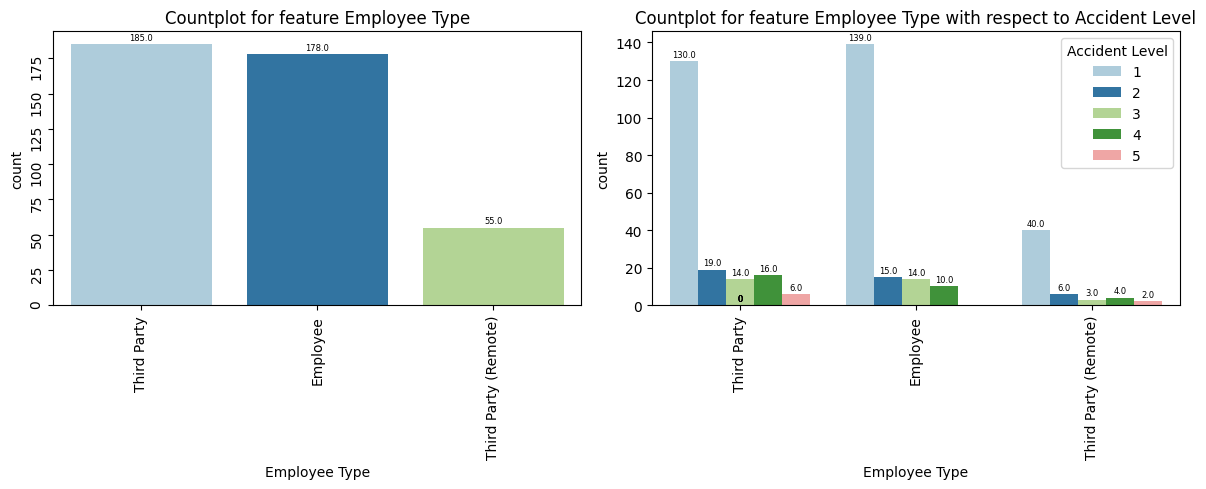

In [ ]:
labeled_barplot(data,'Employee Type', 'Accident Level',perc=False, n=None)

**Observation**

**What are top 5 critical risks which have maximum chance of causing high disaster accident?**

**Univariate Analysis Critical Risk**

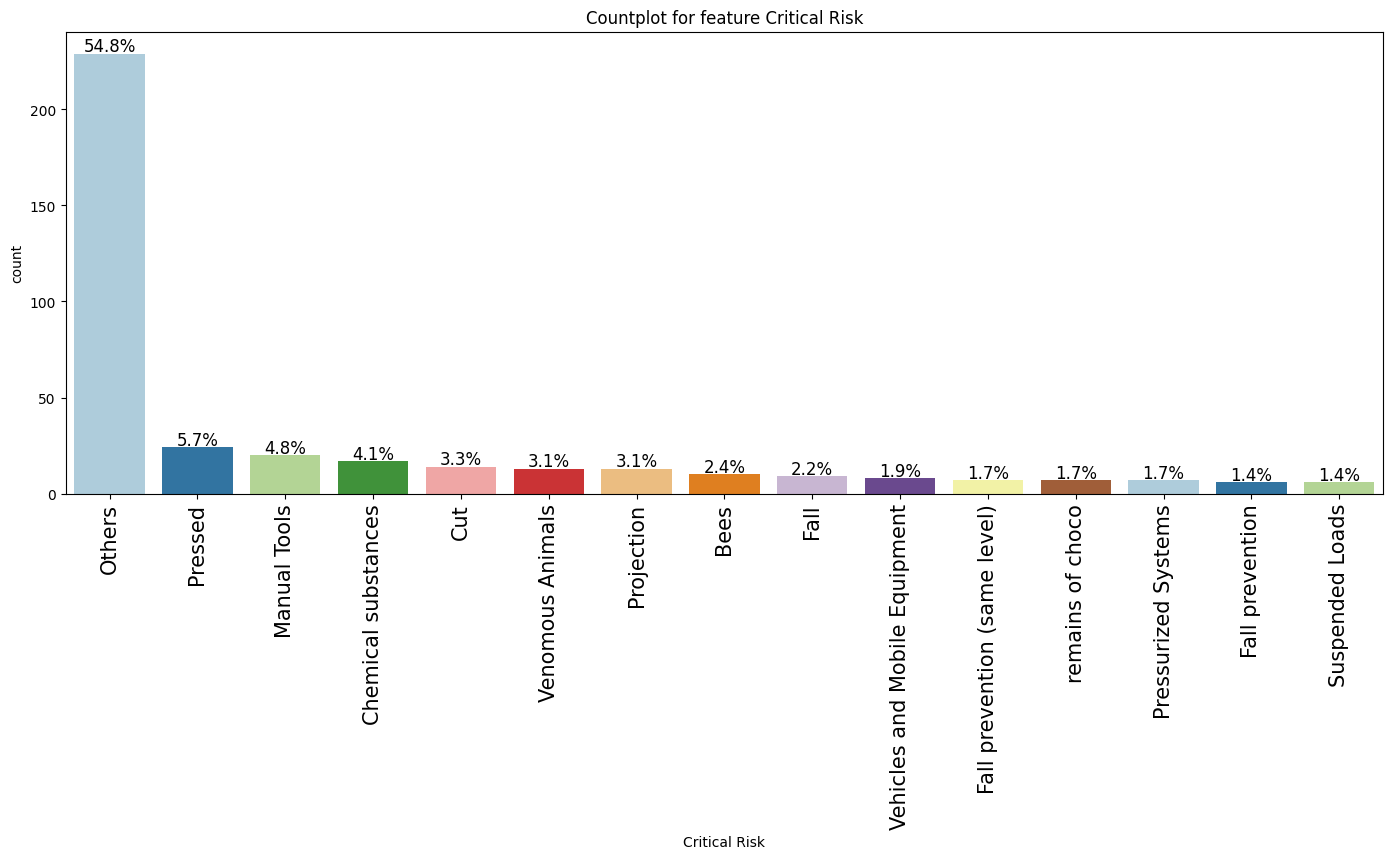

In [49]:
labeled_barplot_uni(data,'Critical Risk',perc=True, n=15)

**Observation**

**Countrywise distribution of Industry Sector-Bivariate Analysis Countries with respect to Industry Sector**

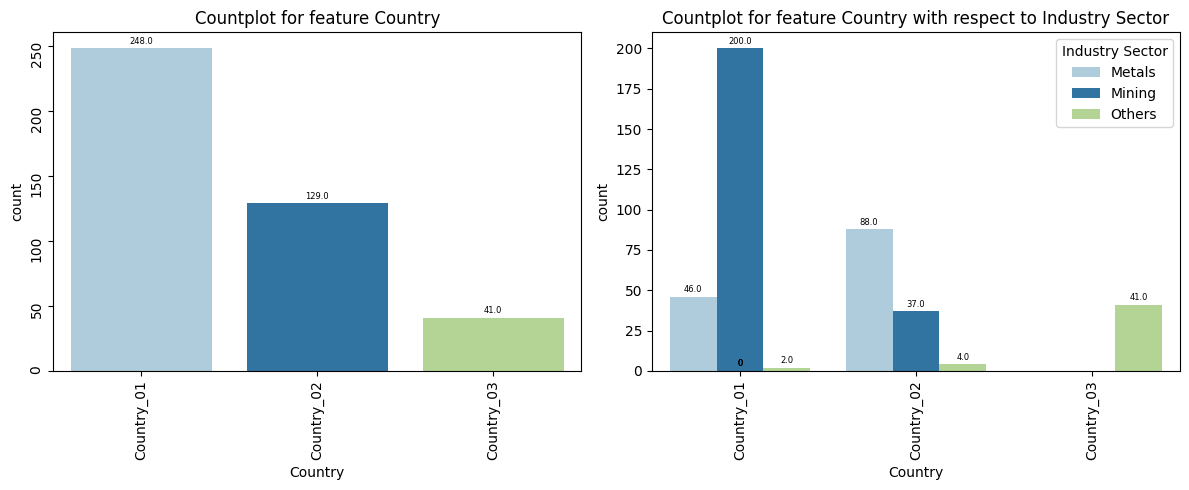

In [ ]:
labeled_barplot(data,'Country', 'Industry Sector',perc=False, n=None)

**Observation**

**Bivariate Analysis Countries with respect to Gender**

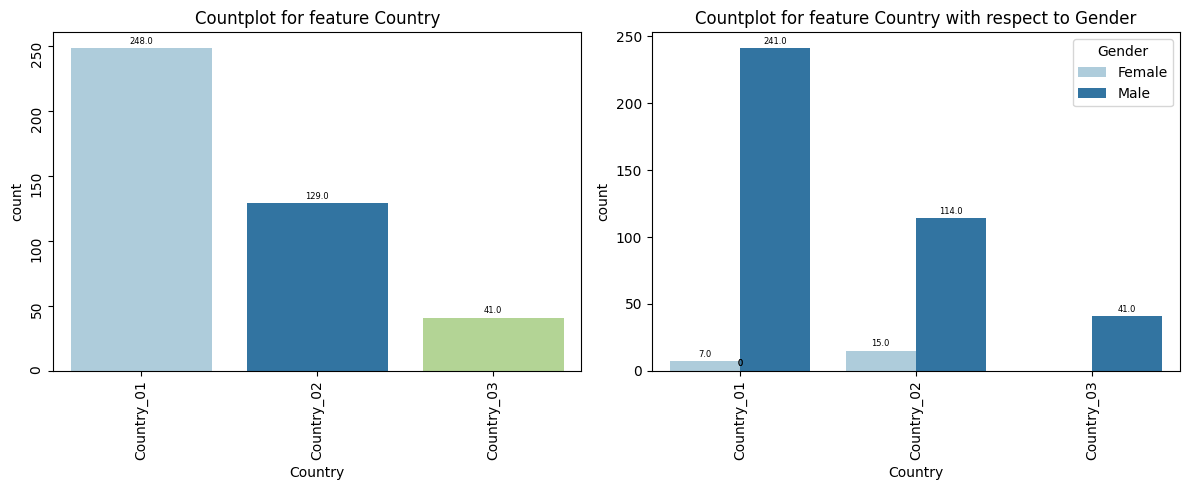

In [ ]:
labeled_barplot(data,'Country', 'Gender',perc=False, n=None)

**Observation**

**Bivariate Analysis Countries with respect to Employee Type**

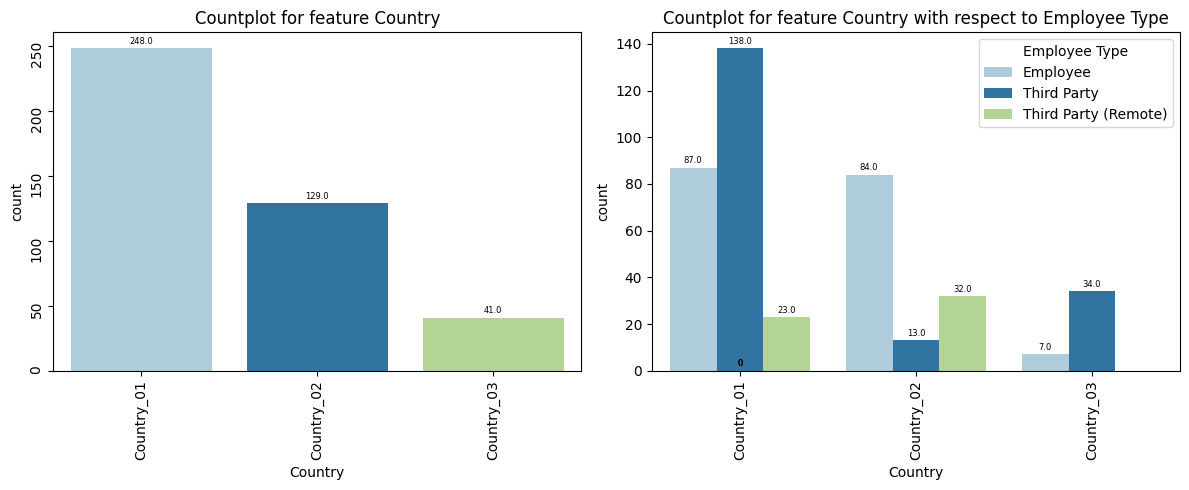

In [ ]:
labeled_barplot(data,'Country', 'Employee Type',perc=False, n=None)

**Observation**

**Bivariate Analysis Industry Sector with respect to Potential Accident Level**

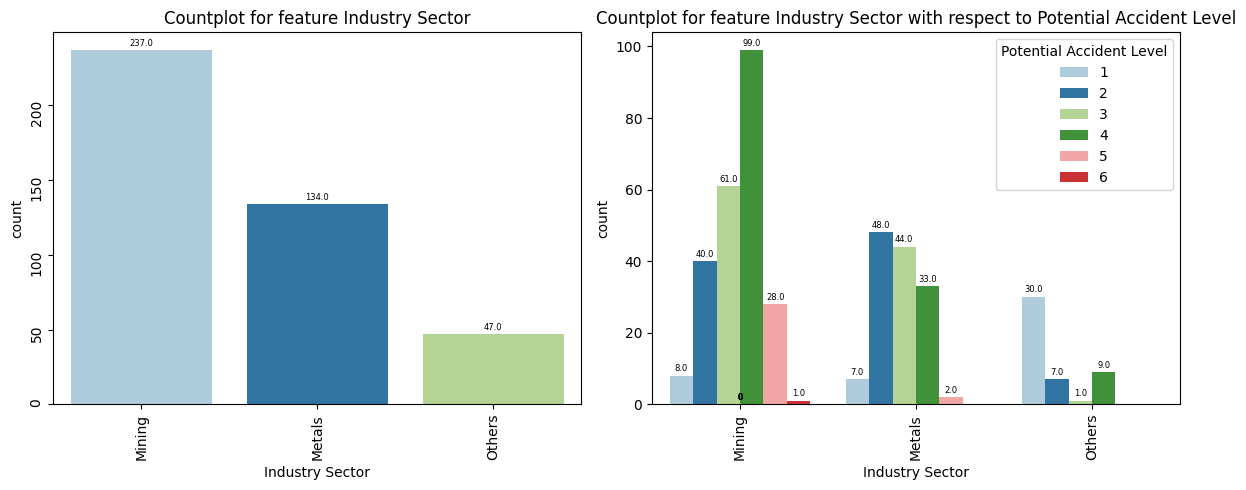

In [ ]:
labeled_barplot(data,'Industry Sector', 'Potential Accident Level',perc=False, n=None)

**Observation**

**Bivariate Analysis Industry Sector with respect to Gender**

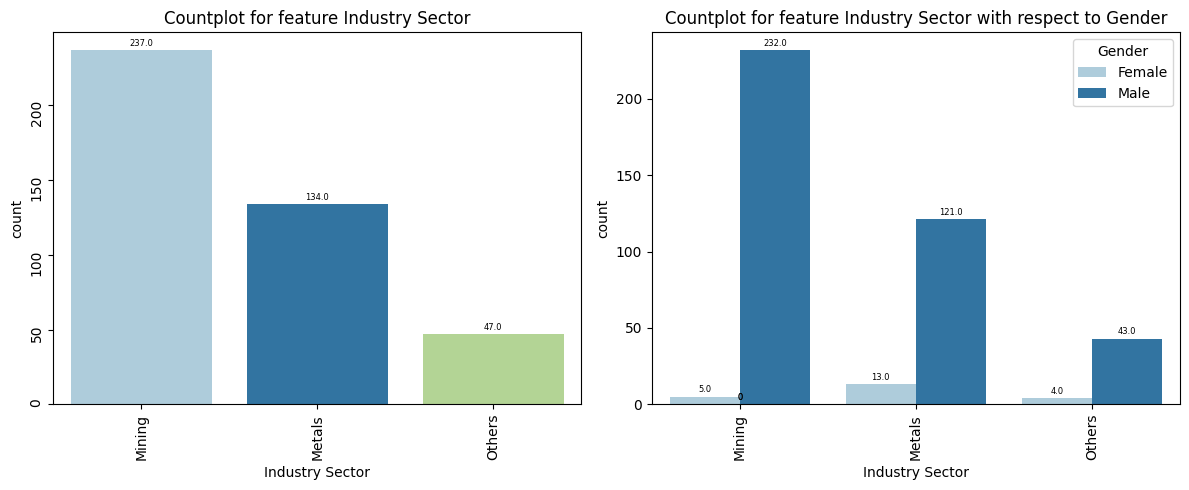

In [ ]:
labeled_barplot(data,'Industry Sector', 'Gender',perc=False, n=None)

**Observation**

**Bivariate Analysis Industry Sector with respect to Employee Type**

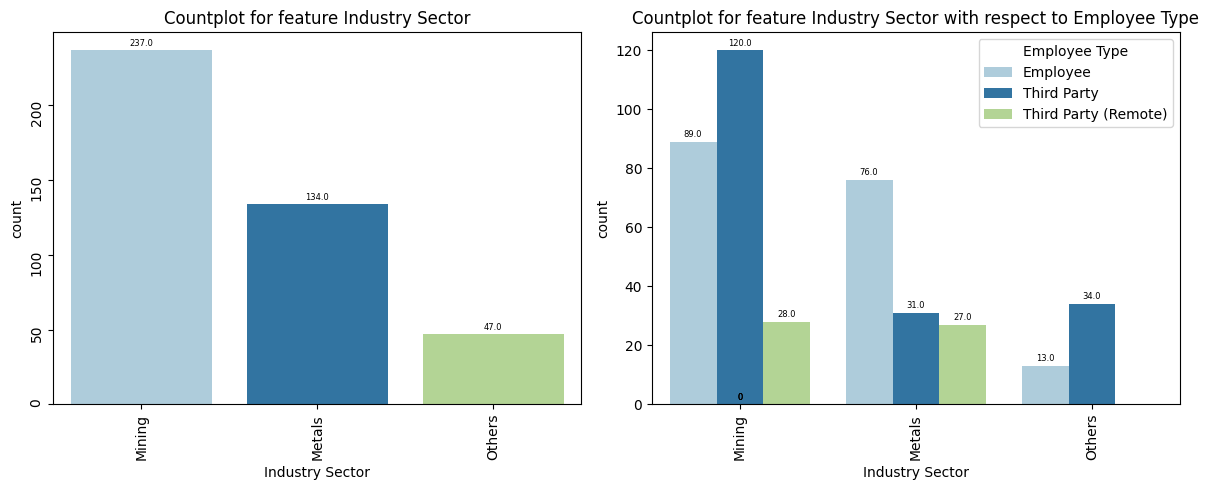

In [ ]:
labeled_barplot(data,'Industry Sector', 'Employee Type',perc=False, n=None)

**Observation**

**Distribution of Employee type by Gender**

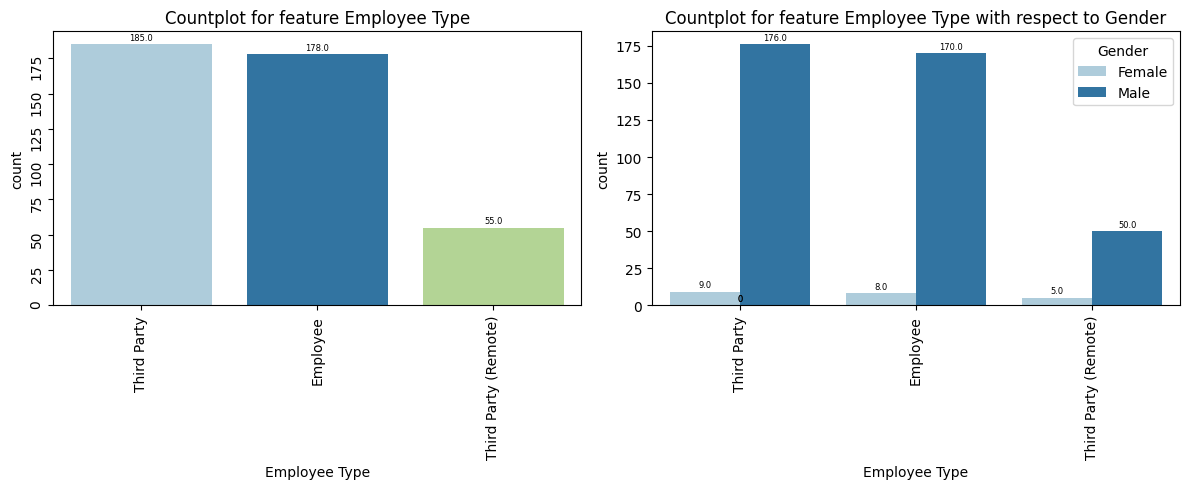

In [ ]:
labeled_barplot(data,'Employee Type','Gender',perc=False, n=None)

**Observation**

**What is year wise distribution of accidents?**

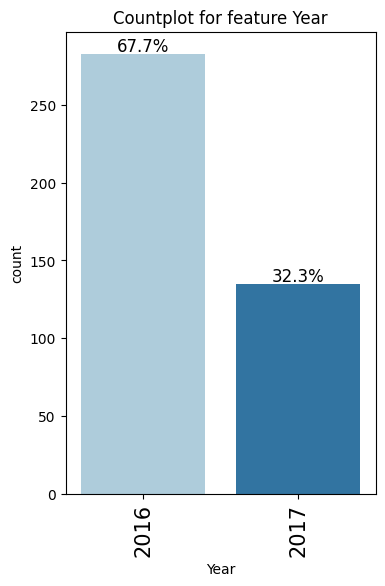

In [41]:
labeled_barplot_uni(data,'Year',perc=True, n=None)

**Observation**

**What is month wise distribution of accidents?**

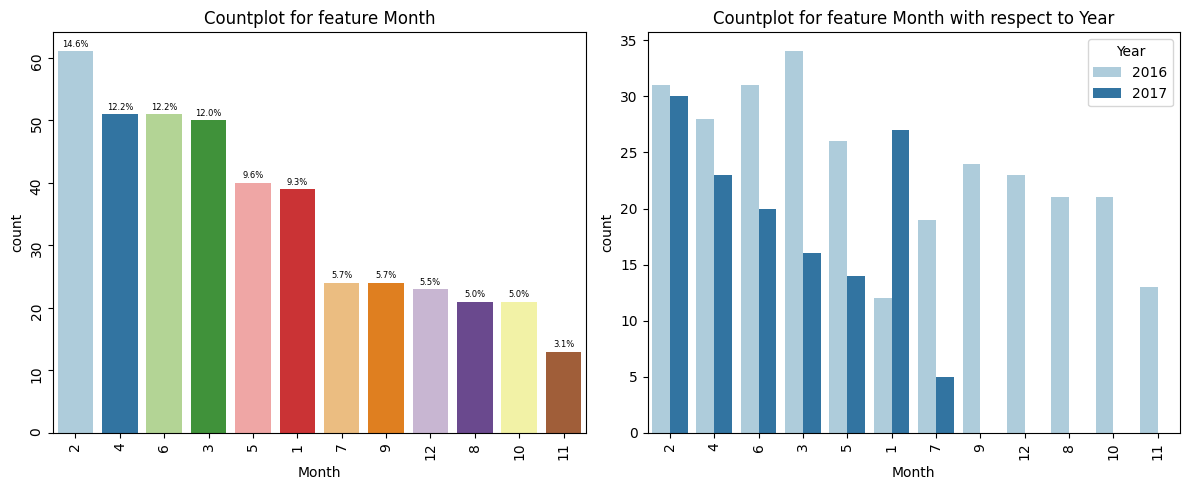

In [42]:
labeled_barplot(data,'Month','Year',perc=True, n=None)

**Observation**

**Which Year has caused maximum high risk accidents?-Accident level by Year**

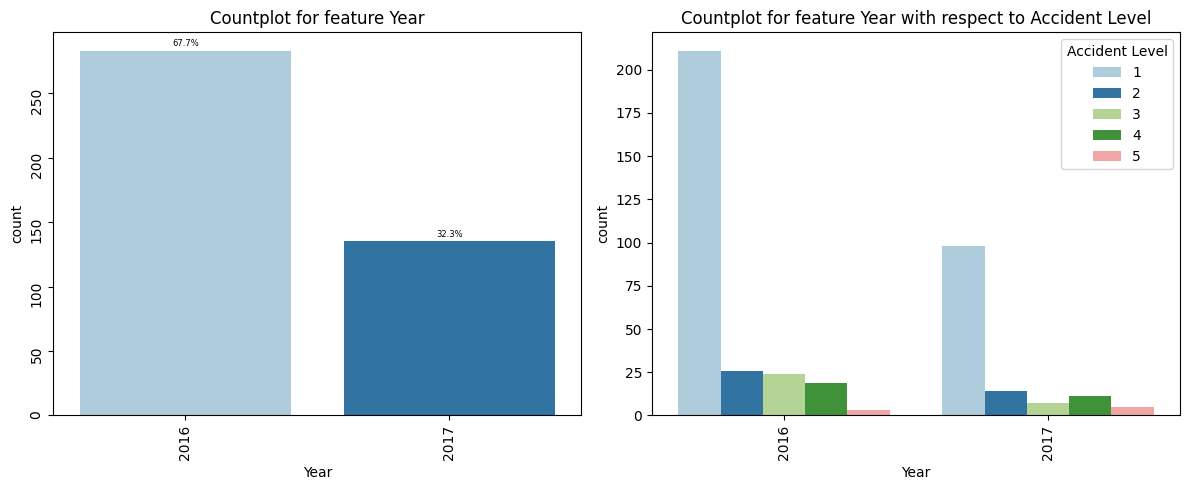

In [43]:
labeled_barplot(data,'Year','Accident Level',perc=True, n=None)

**Observation**

**What is year wise and country wise distribution of accidents?**

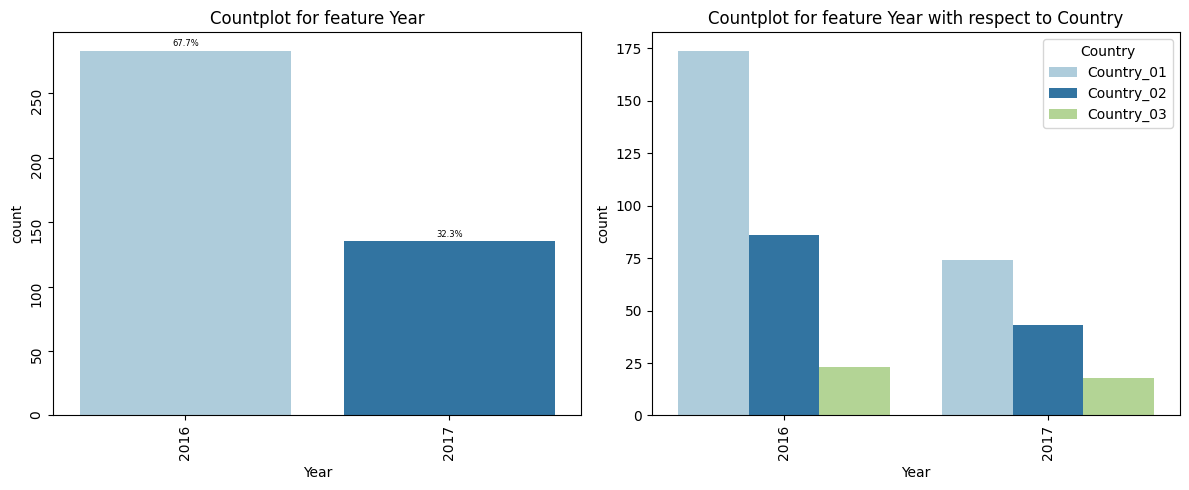

In [48]:
labeled_barplot(data,'Year','Country',perc=True, n=None)

**Observation**

**Which Month has caused maximum high risk accidents?-Accident level by Month**

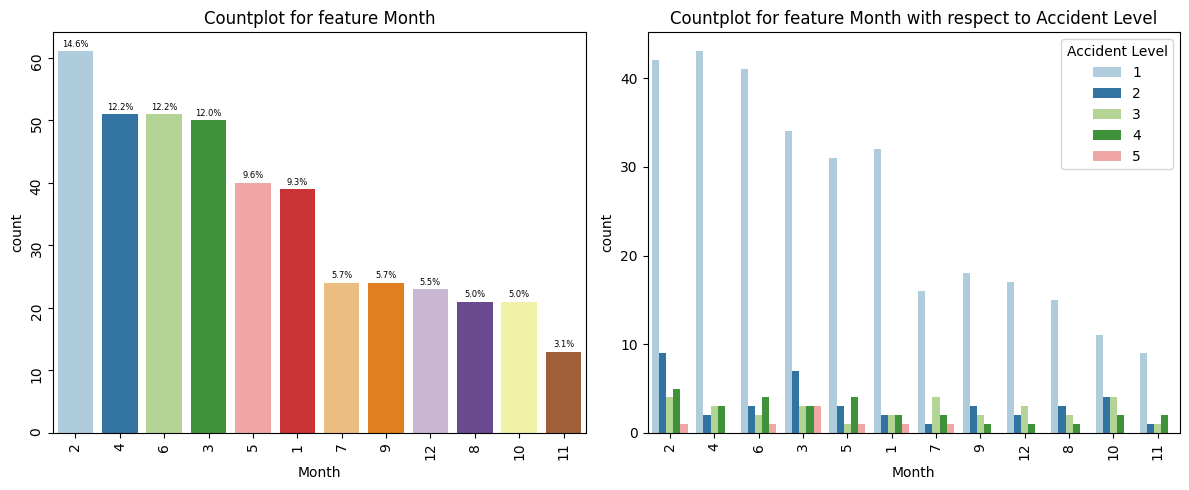

In [44]:
labeled_barplot(data,'Month','Accident Level',perc=True, n=None)

**Observation**

**Yearwise and weekdays wise distribution of accidents data**

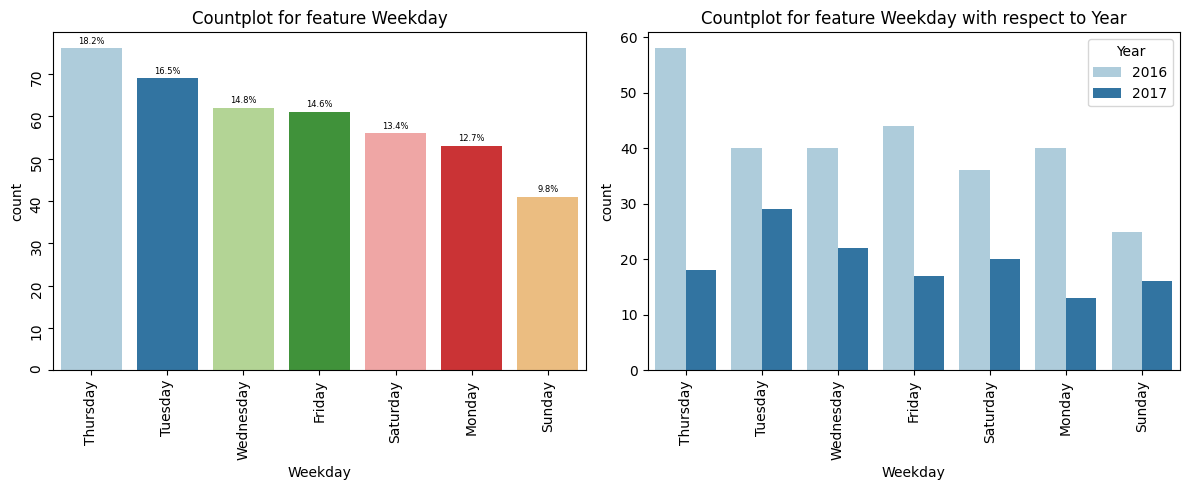

In [46]:
labeled_barplot(data,'Weekday','Year',perc=True, n=None)

**Which Weekday has caused maximum high risk accidents?-Accident level by Weekday**

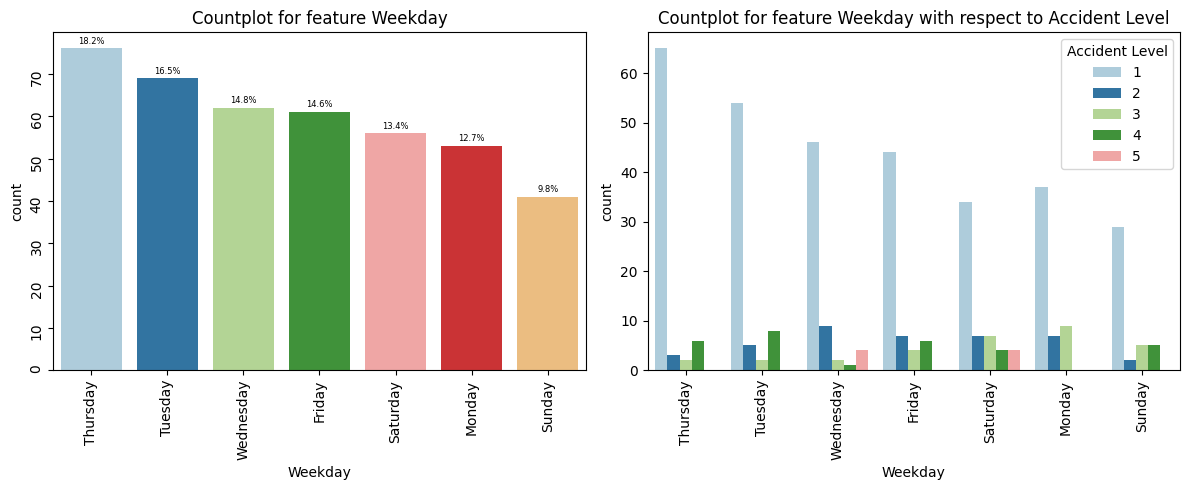

In [47]:
labeled_barplot(data,'Weekday','Accident Level',perc=True, n=None)

**Observation**

**Correlation analysis of input features**

**Chi-Square Test**


Theory: Chi-square test of independence tests the association between two categorical variables. The test is performed via contingency table or a frequency count table between the two variables. Depending on the levels that each variable has, the table’s dimension can be 2X2, 3X3 etc

**Result**

p-value < 0.05, we can reject Null Hypothesis and we can say that there is some relationship between 2 categorical variables

In [53]:
## Let us split this list into two parts
from itertools import product

cat_var1 = ('Country','Local','Industry Sector','Gender','Employee Type','Critical Risk')
cat_var2 = ('Accident Level','Potential Accident Level')
cat_var_prod = list(product(cat_var1,cat_var2, repeat = 1))
cat_var_prod

[('Country', 'Accident Level'),
 ('Country', 'Potential Accident Level'),
 ('Local', 'Accident Level'),
 ('Local', 'Potential Accident Level'),
 ('Industry Sector', 'Accident Level'),
 ('Industry Sector', 'Potential Accident Level'),
 ('Gender', 'Accident Level'),
 ('Gender', 'Potential Accident Level'),
 ('Employee Type', 'Accident Level'),
 ('Employee Type', 'Potential Accident Level'),
 ('Critical Risk', 'Accident Level'),
 ('Critical Risk', 'Potential Accident Level')]

In [54]:
## Creating an empty variable and picking only the p value from the output of Chi-Square test
import scipy.stats as ss

result = []
for i in cat_var_prod:
  if i[0] != i[1]:
    result.append((i[0],i[1],list(ss.chi2_contingency(pd.crosstab(
                            data[i[0]], data[i[1]])))[1]))
result

[('Country', 'Accident Level', np.float64(0.03528174940919625)),
 ('Country', 'Potential Accident Level', np.float64(4.1017395785840915e-34)),
 ('Local', 'Accident Level', np.float64(0.08571572983093331)),
 ('Local', 'Potential Accident Level', np.float64(3.728976101772464e-28)),
 ('Industry Sector', 'Accident Level', np.float64(0.2246610326134543)),
 ('Industry Sector',
  'Potential Accident Level',
  np.float64(1.992985715278311e-36)),
 ('Gender', 'Accident Level', np.float64(0.5634711044097555)),
 ('Gender', 'Potential Accident Level', np.float64(0.0003681748355215793)),
 ('Employee Type', 'Accident Level', np.float64(0.3706872374960308)),
 ('Employee Type', 'Potential Accident Level', np.float64(0.0723131621018394)),
 ('Critical Risk', 'Accident Level', np.float64(1.3248990196998632e-06)),
 ('Critical Risk',
  'Potential Accident Level',
  np.float64(6.463580982130032e-22))]

In [55]:
chi_test_output = pd.DataFrame(result, columns = ['var1', 'var2',
                                                       'coeff'])
## Using pivot function to convert the above DataFrame into a crosstab
chi_test_output.pivot(index='var1', columns='var2', values='coeff')

var2,Accident Level,Potential Accident Level
var1,,
Country,0.035282,4.101740e-34
Critical Risk,0.000001,6.463581e-22
Employee Type,0.370687,7.231316e-02
Gender,0.563471,3.681748e-04
Industry Sector,0.224661,1.992986e-36
Local,0.085716,3.728976e-28
